In [1]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import sys
sys.path.insert(0, '/home/ferjao_k/sw/aare/build')
from aare import fit_gaus, fit_gaus_minuit_grad
from aare import Gaussian, fit

In [2]:
ROWS = 100
COLS = 100
N_SCAN = 100
NOISE_FRAC = 0.3
SEED = 42
N_THREADS = 4

N_REPEATS = 5
N_WARMUP  = 3    # untimed iterations (icache + branch predictor warmup)
COOLDOWN  = 2.0  # seconds between (method, thread_count) pairs

In [3]:
def generate_3d_data(rows, cols, n_scan, noise_frac, seed):
    """
    Generate a synthetic detector image stack where each pixel has a
    Gaussian response curve with per-pixel variation in A, mu, sigma.

    Returns x (n_scan,), y (rows, cols, n_scan), y_err (rows, cols, n_scan),
    and the ground-truth parameter arrays.
    """
    rng = np.random.default_rng(seed)

    # Per-pixel true params each of shape: [rows, cols, 1]
    A_true = rng.uniform(200, 1000, size=(rows, cols))
    mu_true = rng.uniform(20, 80, size=(rows, cols))
    sig_true = rng.uniform(3, 12, size=(rows, cols))
    
    # One common binned energy array
    x = np.linspace(0, 100, n_scan) # shape [1, 1, nscan]

    # Build ground truth signals per-pixel
    exponent = -0.5 * ((x[None, None, :] - mu_true[:, :, None]) / sig_true[:,:, None])**2 # shape [rows, cols, nscan]
    y_clean = A_true[:, :, None] * np.exp(exponent)

    # Perturb with noise
    noise_sigma = noise_frac * A_true[:, :, None] * np.ones_like(y_clean) # shape [rows, cols, nscan]
    noise = rng.normal(0, noise_sigma)
    y = y_clean + noise

    y_err = noise_sigma.copy()

    return x, y, y_err, A_true, mu_true, sig_true    

In [4]:
def bench(fn, n_warmup=N_WARMUP, n_repeats=N_REPEATS):
    """
    Warmup then time `fn` over `n_repeats` calls.
    Returns (last_result, list_of_walltimes_in_seconds).
    """
    # warmup: primes icache, branch predictor, and lets CPU ramp to boost clock
    for _ in range(n_warmup):
        res = fn()

    times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        res = fn()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return res, times

In [5]:
# ===============
# DATA GENERATION
# ===============
print(f"Generating synthetic data: {ROWS}x{COLS} pixels, "
      f"{N_SCAN} scan points, noise_frac={NOISE_FRAC}\n")

x, y, yerr, true_A, true_mu, true_sig = generate_3d_data(
    ROWS, COLS, N_SCAN, NOISE_FRAC, SEED
)

Generating synthetic data: 100x100 pixels, 100 scan points, noise_frac=0.3



In [6]:
model = Gaussian()
METHOD_DEFS = [
    ("lmfit (LM)",
     lambda nt: lambda: fit_gaus(x, y, n_threads=nt),
     "#2196F3", {"linewidth": 3.0, "linestyle": "-"}),

    ("Minuit2 (fct call)",
     lambda nt: lambda: fit_gaus_minuit_grad(x, y, n_threads=nt),
     "#FF9800", {"linewidth": 2.0, "linestyle": "--"}),

    ("Minuit2 (obj API)",
     lambda nt: lambda: fit(model, x, y, n_threads=nt),
     "#4CAF50", {"linewidth": 2.5, "linestyle": ":"}),
]

colors = {label: c for label, _, c, _ in METHOD_DEFS}
styles = {label: s for label, _, _, s in METHOD_DEFS}

In [7]:
# ====================================
# SINGLE-CALL BENCHMARK (at N_THREADS)
# ====================================
def extract_result(label, res):
    """Normalize return values across fitters into a common dict."""
    if isinstance(res, dict):
        out = {"par": res["par"]}
        if "par_err" in res:
            out["par_err"] = res["par_err"]
        if "chi2" in res:
            out["chi2"] = res["chi2"]
        return out
    # fit_gaus without y_err returns a raw array
    return {"par": res}
    
methods = {}
for label, factory, _, _ in METHOD_DEFS:
    time.sleep(COOLDOWN)
    res, times = bench(factory(N_THREADS))
    entry = extract_result(label, res)
    entry["times"] = times
    methods[label] = entry

# ---- Print summary ----
ndf = N_SCAN - 3
print(f"{'Method':24s}  {'time (ms)':>10s}  {'med|dA|':>10s}  {'med|dMu|':>10s}  {'med|dSig|':>10s}")
print("-" * 80)
for name, m in methods.items():
    par   = m["par"]
    med_t = np.median(m["times"]) * 1e3
    dA    = np.median(np.abs(par[:,:,0] - true_A))
    dMu   = np.median(np.abs(par[:,:,1] - true_mu))
    dSig  = np.median(np.abs(par[:,:,2] - true_sig))

    chi2_str = ""
    if "chi2" in m:
        chi2_str = f"  chi2/ndf={np.median(m['chi2'] / ndf):.4f}"

    print(f"[{name:22s}]  {med_t:8.2f} ms  "
          f"{dA:10.3f}  {dMu:10.4f}  {dSig:10.4f}{chi2_str}")

Method                     time (ms)     med|dA|    med|dMu|   med|dSig|
--------------------------------------------------------------------------------
[lmfit (LM)            ]    362.10 ms      38.180      0.5711      0.5793
[Minuit2 (fct call)    ]    546.10 ms      38.181      0.5719      0.5793  chi2/ndf=31796.2801
[Minuit2 (obj API)     ]    207.54 ms      39.043      0.5835      0.5949  chi2/ndf=31638.9234


In [8]:
# ===============
# THREAD SCALING
# ===============
thread_counts = [1, 2, 4, 8]

thread_times  = {label: [] for label, _, _, _ in METHOD_DEFS}
ttimes_stddev = {label: [] for label, _, _, _ in METHOD_DEFS}

for nt in thread_counts:
    # shuffle method order per thread count to decorrelate thermal bias
    run_order = list(METHOD_DEFS)
    random.shuffle(run_order)

    for label, factory, _, _ in run_order:
        time.sleep(COOLDOWN)
        _, times = bench(factory(nt))

        med = np.median(times) * 1e3
        std = np.std(times) * 1e3
        thread_times[label].append(med)
        ttimes_stddev[label].append(std)

        per_px     = med / (ROWS * COLS) * 1e3
        per_px_std = std / (ROWS * COLS) * 1e3
        print(f"  {label:22s}  n_threads={nt:2d}  "
              f"{med:8.2f} ± {std:6.2f} ms  "
              f"({per_px:.4f} ± {per_px_std:.4f} μs/pixel)")

  Minuit2 (obj API)       n_threads= 1    778.03 ±   2.53 ms  (77.8034 ± 0.2535 μs/pixel)
  Minuit2 (fct call)      n_threads= 1   1349.72 ±   1.74 ms  (134.9715 ± 0.1736 μs/pixel)
  lmfit (LM)              n_threads= 1   1364.05 ±   2.74 ms  (136.4048 ± 0.2742 μs/pixel)
  lmfit (LM)              n_threads= 2    696.15 ±   2.89 ms  (69.6153 ± 0.2889 μs/pixel)
  Minuit2 (fct call)      n_threads= 2    690.21 ±   1.22 ms  (69.0214 ± 0.1220 μs/pixel)
  Minuit2 (obj API)       n_threads= 2    396.62 ±   1.50 ms  (39.6620 ± 0.1497 μs/pixel)
  lmfit (LM)              n_threads= 4    365.27 ±   6.90 ms  (36.5268 ± 0.6904 μs/pixel)
  Minuit2 (obj API)       n_threads= 4    205.83 ±   6.17 ms  (20.5831 ± 0.6171 μs/pixel)
  Minuit2 (fct call)      n_threads= 4    357.90 ±   6.00 ms  (35.7899 ± 0.6001 μs/pixel)
  Minuit2 (obj API)       n_threads= 8    230.51 ±  19.03 ms  (23.0508 ± 1.9030 μs/pixel)
  Minuit2 (fct call)      n_threads= 8    390.93 ±   5.38 ms  (39.0928 ± 0.5381 μs/pixel)
  lmfit 

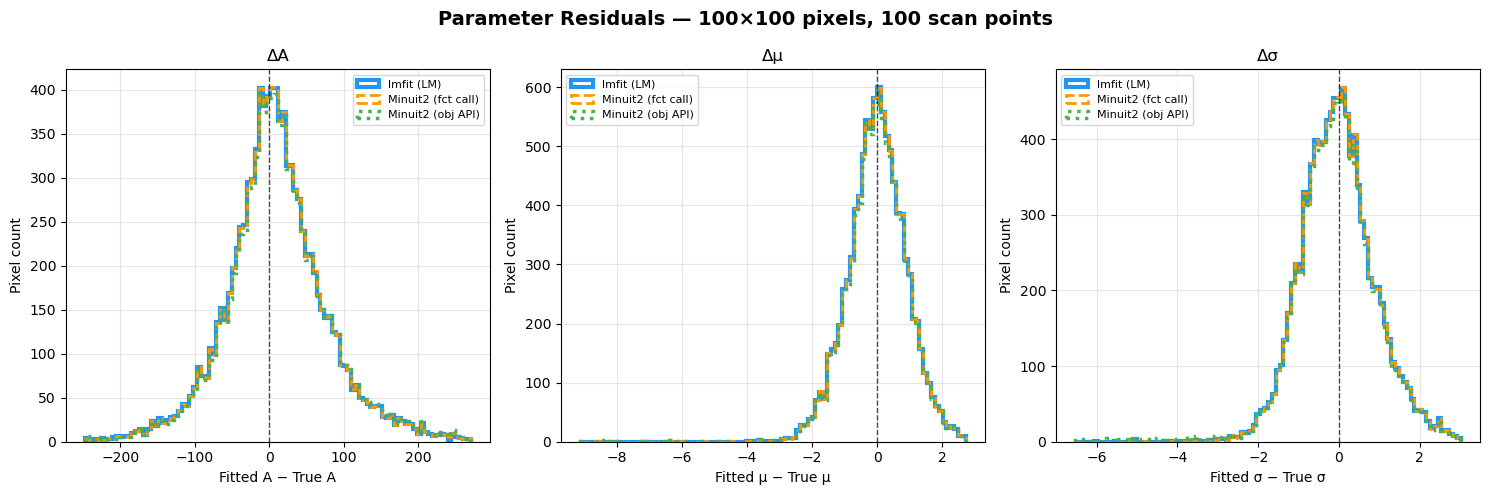

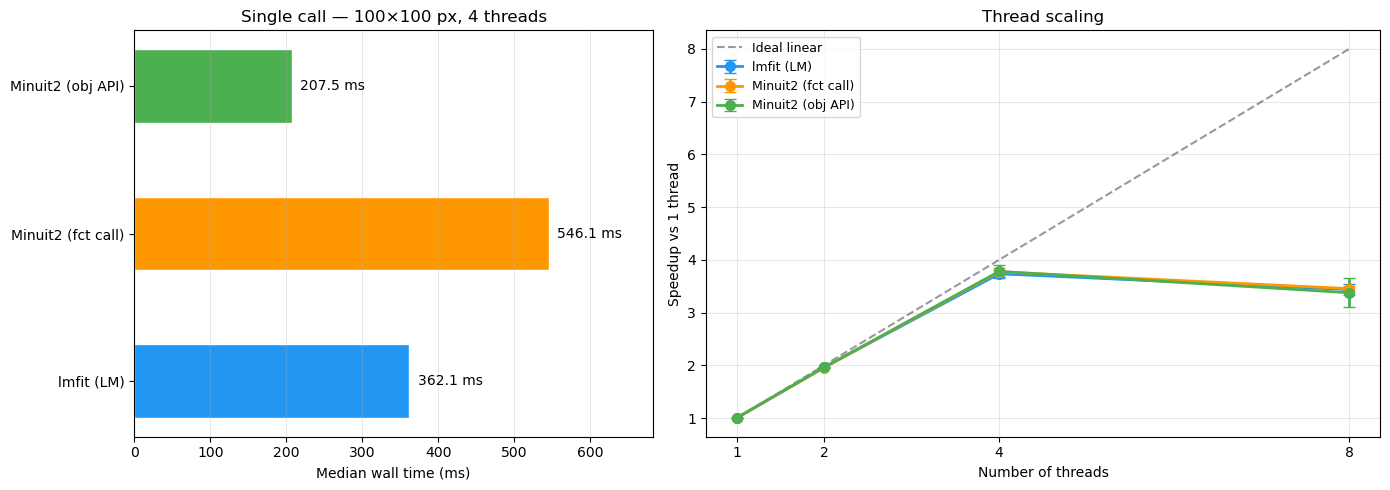

In [9]:
# =============================
# FIGURE 1: Residual histograms
# =============================
param_names  = ["A", "μ", "σ"]
param_truths = [true_A, true_mu, true_sig]

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
fig1.suptitle(f"Parameter Residuals — {ROWS}×{COLS} pixels, {N_SCAN} scan points",
              fontsize=14, fontweight="bold")

for col, (pname, truth) in enumerate(zip(param_names, param_truths)):
    ax = axes1[col]

    # collect residuals across all methods for shared bin edges
    res_by_method = {}
    all_res = []
    for mname, m in methods.items():
        residual = (m["par"][:, :, col] - truth).ravel()
        res_by_method[mname] = residual
        all_res.append(residual)
    all_res = np.concatenate(all_res)

    lo, hi = np.percentile(all_res, [0.5, 99.5])
    edges  = np.linspace(lo, hi, 101)

    for mname, r in res_by_method.items():
        ax.hist(r, bins=edges, histtype="step", label=mname,
                color=colors[mname],
                linewidth=styles[mname]["linewidth"],
                linestyle=styles[mname]["linestyle"])

    ax.axvline(0, color="k", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel(f"Fitted {pname} − True {pname}")
    ax.set_ylabel("Pixel count")
    ax.set_title(f"Δ{pname}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig1.tight_layout()
# fig1.savefig("fig1_residual_histograms.png", dpi=150, bbox_inches="tight")
# print("\nSaved fig1_residual_histograms.png")

# ====================================================
# FIGURE 2: Performance — bar chart + thread scaling
# ====================================================
fig2 = plt.figure(figsize=(14, 5))
gs   = GridSpec(1, 2, figure=fig2, width_ratios=[1, 1.3])

# -- Left: bar chart at N_THREADS --
ax2a    = fig2.add_subplot(gs[0])
names   = list(methods.keys())
medians = [np.median(methods[n]["times"]) * 1e3 for n in names]
bars    = ax2a.barh(names, medians,
                    color=[colors[n] for n in names],
                    edgecolor="white", height=0.5)
ax2a.set_xlabel("Median wall time (ms)")
ax2a.set_title(f"Single call — {ROWS}×{COLS} px, {N_THREADS} threads")
for bar, val in zip(bars, medians):
    ax2a.text(bar.get_width() + max(medians) * 0.02,
              bar.get_y() + bar.get_height() / 2,
              f"{val:.1f} ms", va="center", fontsize=10)
ax2a.grid(axis="x", alpha=0.3)
ax2a.set_xlim(0, max(medians) * 1.25)

# -- Right: thread scaling with error bars --
ax2b = fig2.add_subplot(gs[1])
for label, _, _, _ in METHOD_DEFS:
    tt = thread_times[label]
    sd = ttimes_stddev[label]
    speedup     = [tt[0] / t for t in tt]
    # propagate uncertainty: S = t0/t  →  δS/S = sqrt((δt0/t0)² + (δt/t)²)
    speedup_err = [
        s * np.sqrt((sd[0] / tt[0])**2 + (sd[i] / tt[i])**2)
        for i, s in enumerate(speedup)
    ]
    ax2b.errorbar(thread_counts, speedup, yerr=speedup_err,
                  fmt="o-", label=label, color=colors[label],
                  linewidth=2, markersize=7, capsize=4)

ax2b.plot(thread_counts, thread_counts, "k--", alpha=0.4, label="Ideal linear")
ax2b.set_xlabel("Number of threads")
ax2b.set_ylabel("Speedup vs 1 thread")
ax2b.set_title("Thread scaling")
ax2b.set_xticks(thread_counts)
ax2b.legend(fontsize=9)
ax2b.grid(alpha=0.3)

fig2.tight_layout()
# fig2.savefig("fig2_performance.png", dpi=150, bbox_inches="tight")
# print("Saved fig2_performance.png")

plt.show()